In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Dataset

In [3]:
class RawFeatureDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.df = df.copy()
        self.df['deceptive'] = self.df['deceptive'].astype(int)
        self.feature_cols = feature_cols
        self.sample_ids = self.df['id'].unique().tolist()

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        subset = self.df[self.df['id'] == sample_id]
        X = subset[self.feature_cols].values.astype(np.float32)
        y = subset['deceptive'].iloc[0]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    
def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = [len(seq) for seq in sequences]
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=-10.0)
    return padded_sequences, torch.tensor(lengths), torch.tensor(labels, dtype=torch.float32)

In [4]:
class FeatureEngineeredDataset(Dataset):
    def __init__(self, df, 
                 use_raw=True,
                 use_distances=True,
                 use_velocity=True,
                 zero_center=True,
                 dist_scale=100.0,
                 velocity_scale=1000.0,
                 noise_level=0.0):
        
        self.df = df.copy()
        self.sample_ids = self.df['id'].unique().tolist()
        self.df['deceptive'] = self.df['deceptive'].astype(int)

        self.use_raw = use_raw
        self.use_distances = use_distances
        self.use_velocity = use_velocity
        self.zero_center = zero_center
        self.dist_scale = dist_scale
        self.velocity_scale = velocity_scale
        self.noise_level = noise_level

        self.raw_cols = ['flow_mean_x', 'flow_mean_y', 'flow_std_x', 'flow_std_y',
                          'Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
        
        # vertical face height
        self.FACE_TOP = 10
        self.FACE_BOTTOM = 152
        # facial landmark indices
        self.LIPS_V = [13, 14]      # Mouth open/close
        self.LIPS_H = [61, 291]     # Mouth widen/pucker
        self.EYE_L = [159, 145]     # Left Eye blink
        self.EYE_R = [386, 374]     # Right Eye blink
        self.BROW_L = [65, 159]     # Left Brow raise
        self.BROW_R = [295, 386]    # Right Brow raise


    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        subset = self.df[self.df['id'] == sample_id].reset_index(drop=True)
        features_list = []

        if self.use_raw:
            raw = subset[self.raw_cols].values.astype(np.float32)
            raw = np.nan_to_num(raw, nan=0.0)
            features_list.append(raw)

        if self.use_distances or self.use_velocity:
            landmark_data = subset.filter(regex='^lm_').values.astype(np.float32)

            sequence_length = len(subset)
            num_landmarks = landmark_data.shape[1] // 2

            try:
                landmarks = landmark_data.reshape(sequence_length, num_landmarks, 2)
            except ValueError:
                expected_size = (11 if self.use_raw else 0) + (6 if self.use_distances else 0) + (6 if self.use_velocity else 0)
                return torch.zeros((sequence_length, expected_size), dtype=torch.float32), torch.tensor(0.0, dtype=torch.float32)

            face_height = np.linalg.norm(landmarks[:, self.FACE_TOP] - landmarks[:, self.FACE_BOTTOM], axis=1)
            face_height = np.clip(face_height, 1e-6, None)

            def get_dist(idx1, idx2):
                return np.linalg.norm(landmarks[:, idx1] - landmarks[:, idx2], axis=1) / face_height
        
            dist_features = np.stack([
                get_dist(self.LIPS_V[0], self.LIPS_V[1]),
                get_dist(self.LIPS_H[0], self.LIPS_H[1]),
                get_dist(self.EYE_L[0], self.EYE_L[1]),
                get_dist(self.EYE_R[0], self.EYE_R[1]),
                get_dist(self.BROW_L[0], self.BROW_L[1]),
                get_dist(self.BROW_R[0], self.BROW_R[1])
            ], axis=1)

            if self.zero_center: 
                dist_features = dist_features - np.mean(dist_features, axis=0)

            if self.use_distances:
                features_list.append(dist_features * self.dist_scale)
            
            if self.use_velocity:
                velocity = np.diff(dist_features, axis=0, prepend=dist_features[:1])
                features_list.append(velocity * self.velocity_scale)

        X = np.concatenate(features_list, axis=1)
        if self.noise_level > 0.0:
            noise = np.random.normal(0, self.noise_level, X.shape).astype(np.float32)
            X += noise

        y = subset['deceptive'].iloc[0]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [ ]:
df = pd.read_csv("../processed_data/silesian_deception_dataset/emotions_landmarks_flow.csv")
bad_rows = df[df.isna().any(axis=1)]
bad_ids = bad_rows['id'].unique().tolist()
df = df[~df['id'].isin(bad_ids)].reset_index(drop=True)

samples = df['id'].unique().tolist()
sample_labels = df.groupby('id')['deceptive'].first().values
train_samples, test_samples = train_test_split(samples, test_size=0.2, random_state=42, stratify=sample_labels)
train_df = df[df['id'].isin(train_samples)].copy()
test_df = df[df['id'].isin(test_samples)].copy()

landmarks_cols = [f'lm_{i}' for i in range(468*2)]
flow_cols = ['flow_mean_x', 'flow_mean_y', 'flow_std_x', 'flow_std_y']
emotion_cols = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
all_feature_cols = landmarks_cols + flow_cols + emotion_cols

scalers = {}
for cols in [flow_cols, emotion_cols]:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_df[cols] = scaler.fit_transform(train_df[cols])
    test_df[cols] = scaler.transform(test_df[cols])
    scalers.update({col: scaler for col in cols})

# train_dataset = RawFeatureDataset(train_df, all_feature_cols)
# test_dataset = RawFeatureDataset(test_df, all_feature_cols)


# labels = train_df.groupby("id")["deceptive"].first().values
# class_sample_count = np.array([len(np.where(labels==0)[0]), len(np.where(labels==1)[0])])
# weight = 1. / class_sample_count
# samples_weight = np.array([weight[int(l)] for l in labels])
# samples_weight = torch.from_numpy(samples_weight).float()
# sampler = WeightedRandomSampler(samples_weight, len(samples_weight))


In [5]:
train_dataset = FeatureEngineeredDataset(train_df, use_raw=True, use_velocity=False, noise_level=0.05)
test_dataset = FeatureEngineeredDataset(test_df, use_raw=True, use_velocity=False)
train_loader = DataLoader(train_dataset, batch_size=16, collate_fn=collate_fn, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=16, collate_fn=collate_fn, shuffle=False, drop_last=True)

In [6]:
num_pos_videos = sum([train_dataset[i][1].item() == 1 for i in range(len(train_dataset))])
num_neg_videos = len(train_dataset) - num_pos_videos
pos_weight = torch.tensor(num_neg_videos / num_pos_videos, dtype=torch.float32).to(device)

print(f"Number of positive samples: {num_pos_videos}, Number of negative samples: {num_neg_videos}")

Number of positive samples: 501, Number of negative samples: 232


# BiLSTM with attention

In [5]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out, mask):
        scores = self.attn(lstm_out).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e4)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        # weights = torch.nan_to_num(weights, nan=0.0)
        context = torch.sum(weights * lstm_out, dim=1)
        return context, weights

class BiLSTMAttention(nn.Module):
    def __init__(self, input_dim=17, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()

        # self.feature_extractor = nn.Sequential(
        #     nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
        #     nn.BatchNorm1d(hidden_dim),
        #     nn.ReLU(),
        #     nn.Dropout(dropout / 2),
        # )

        self.lstm = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.attn = Attention(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x, lengths):
        # x = x.permute(0, 2, 1)
        # x = self.feature_extractor(x)
        # x = x.permute(0, 2, 1)

        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)

        mask = torch.arange(out.size(1), device=out.device)[None, :] < lengths[:, None].to(out.device)
        context, weights = self.attn(out, mask)

        logits = self.classifier(context).squeeze(1)
        return logits, weights

In [6]:
def find_best_threshold(y_true, y_probs):
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in np.arange(0.1, 0.91, 0.01):
        preds = (y_probs >= thresh).astype(int)
        score = f1_score(y_true, preds)
        
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    return best_thresh, best_f1

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for X, lengths, y in loader:
            X, y = X.to(device), y.to(device)
            
            logits, _ = model(X, lengths)
            probs = torch.sigmoid(logits)
            
            preds = (probs > 0.5).float()
            
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = 0.5
    
    best_thresh, best_f1 = find_best_threshold(y_true, y_prob)
    
    best_preds = (y_prob >= best_thresh).astype(int)
    acc_at_best = accuracy_score(y_true, best_preds)
    
    return {"acc": acc, "f1": f1, "auc": auc, "best_thresh": best_thresh, "best_f1": best_f1, "acc_at_best": acc_at_best}

# Training

In [ ]:
def train(
        model,
        optimizer, 
        criterion, 
        train_loader, 
        eval_loader, 
        scheduler=None,
        num_epochs=100, 
        early_stop=False,
        early_stop_patience=25,
        save_best_model_path="../model_weights/best_model.pt",
        scorer="auc",
        mode="max",
        load_best_model=False
        ):
    best_score = float('-inf') if mode == 'max' else float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for X, lengths, y in train_loader:
            X, lengths, y = X.to(device), lengths.to(device), y.to(device)

            optimizer.zero_grad()

            logits, _ = model(X, lengths)
            loss = criterion(logits, y)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
        
        train_loss = total_loss / len(train_loader)
        metrics = evaluate(model, eval_loader)
        current_score = metrics[scorer]
        
        print(f"Epoch {epoch+1}: Loss={train_loss:.4f} | AUC={metrics['auc']:.4f} | Best F1={metrics['best_f1']:.3f} (Thresh={metrics['best_thresh']:.2f}) | Acc={metrics['acc_at_best']:.3f}")
        if scheduler:
            scheduler.step(current_score)
        
        if (current_score > best_score and mode == "max") or (current_score < best_score and mode == "min"):
            best_score = current_score
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_best_model_path)
        else:
            epochs_no_improve += 1

            if early_stop and epochs_no_improve >= early_stop_patience:
                print("Early stopping.")
                break

    if load_best_model:
        model.load_state_dict(torch.load(save_best_model_path))

## Overfit Check

In [ ]:
INPUT_DIM = 17 
model = BiLSTMAttention(input_dim=INPUT_DIM, dropout=0.0).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

X_batch, lengths_batch, y_batch = next(iter(train_loader))
X_batch, lengths_batch, y_batch = X_batch.to(device), lengths_batch.to(device), y_batch.to(device)

print(f"--- FEATURE ENGINEERED CHECK (Input Dim: {INPUT_DIM}) ---")

for i in range(1000):
    opt.zero_grad()
    logits, _ = model(X_batch, lengths_batch)
    loss = criterion(logits, y_batch)
    loss.backward()
    opt.step()
    
    if i % 50 == 0:
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y_batch).float().mean()
        print(f"Iter {i}: Loss {loss.item():.4f} | Acc {acc.item():.2f}")

--- FEATURE ENGINEERED CHECK (Input Dim: 17) ---
Iter 0: Loss 0.6988 | Acc 0.44
Iter 50: Loss 0.4980 | Acc 0.66
Iter 100: Loss 0.8079 | Acc 0.72
Iter 150: Loss 0.2552 | Acc 0.88
Iter 200: Loss 0.4835 | Acc 0.72
Iter 250: Loss 0.1948 | Acc 0.91
Iter 300: Loss 0.1352 | Acc 0.94
Iter 350: Loss 0.3451 | Acc 0.84
Iter 400: Loss 0.3886 | Acc 0.78
Iter 450: Loss 0.2094 | Acc 0.88
Iter 500: Loss 0.1844 | Acc 0.97
Iter 550: Loss 0.2222 | Acc 0.97
Iter 600: Loss 0.0920 | Acc 0.97
Iter 650: Loss 0.1061 | Acc 0.97
Iter 700: Loss 0.0549 | Acc 0.97
Iter 750: Loss 0.0735 | Acc 0.97
Iter 800: Loss 0.6723 | Acc 0.72
Iter 850: Loss 0.0842 | Acc 0.97
Iter 900: Loss 1.3038 | Acc 0.66
Iter 950: Loss 0.5225 | Acc 0.72


In [10]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, logits=True, reduce=True):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.logits = logits
        self.reduce = reduce
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        if self.logits:
            bce_loss = self.bce(inputs, targets)
        else:
            bce_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        
        pt = torch.exp(-bce_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * bce_loss

        if self.reduce:
            return torch.mean(F_loss)
        else:
            return F_loss

In [ ]:
model = BiLSTMAttention(input_dim=17, hidden_dim=32, dropout=0.5).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, verbose=True)
criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

train(model, optimizer, criterion, train_loader, test_loader, scheduler=scheduler, early_stop=True, early_stop_patience=25, load_best_model=True)

# # early stopping parameters
# early_stop_patience = 25
# best_val_auc = float('-inf')
# epochs_no_improve = 0

# for epoch in range(100):
#     model.train()
#     total_loss = 0

#     for X, lengths, y in train_loader:
#         X, lengths, y = X.to(device), lengths.to(device), y.to(device)

#         optimizer.zero_grad()

#         logits, _ = model(X, lengths)
#         loss = criterion(logits, y)
#         loss.backward()
        
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
        
#         total_loss += loss.item()
    
#     train_loss = total_loss / len(train_loader)
#     metrics = evaluate(model, test_loader)

#     print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f} | AUC={metrics['auc']:.4f} | Best F1={metrics['best_f1']:.3f} (Thresh={metrics['best_thresh']:.2f}) | Acc={metrics['acc_at_best']:.3f}")

#     scheduler.step(metrics['auc'])
    
#     if metrics['auc'] > best_val_auc:
#         best_val_auc = metrics['auc']
#         epochs_no_improve = 0
#         torch.save(model.state_dict(), "model_weights/best_model.pt")
#     else:
#         epochs_no_improve += 1
#         if epochs_no_improve >= early_stop_patience:
#             print("Early stopping.")
#             break

Epoch 1: Loss=0.0403 | AUC=0.4741 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 2: Loss=0.0398 | AUC=0.4774 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 3: Loss=0.0395 | AUC=0.5085 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 4: Loss=0.0394 | AUC=0.5280 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 5: Loss=0.0391 | AUC=0.5373 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 6: Loss=0.0392 | AUC=0.5330 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 7: Loss=0.0389 | AUC=0.5424 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 8: Loss=0.0394 | AUC=0.5555 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 9: Loss=0.0382 | AUC=0.5797 | Best F1=0.818 (Thresh=0.51) | Acc=0.693
Epoch 10: Loss=0.0378 | AUC=0.5878 | Best F1=0.818 (Thresh=0.49) | Acc=0.693
Epoch 11: Loss=0.0380 | AUC=0.5751 | Best F1=0.818 (Thresh=0.51) | Acc=0.693
Epoch 12: Loss=0.0379 | AUC=0.5988 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 13: Loss=0.0380 | AUC=0.5955 | Best F1=0.815 (Thresh=0.10) | Acc=0.688
Epoch 14

# Transfer learning on different dataset

In [8]:
real_life_df = pd.read_csv("processed_data/real_life_deception_detection_dataset/emotions_landmarks_flow.csv")
rl_train_df, rl_test_df = train_test_split(real_life_df, test_size=0.2, random_state=42, stratify=real_life_df['deceptive'])

rl_train_dataset = FeatureEngineeredDataset(rl_train_df, use_raw=True, use_distances=True, use_velocity=False, noise_level=0.05)
rl_test_dataset = FeatureEngineeredDataset(rl_test_df, use_raw=True, use_distances=True, use_velocity=False, noise_level=0.0)

rl_train_loader = DataLoader(rl_train_dataset, batch_size=16, collate_fn=collate_fn, shuffle=True, drop_last=True)
rl_test_loader = DataLoader(rl_test_dataset, batch_size=16, collate_fn=collate_fn, shuffle=False, drop_last=False)

model = BiLSTMAttention(input_dim=17, hidden_dim=32, dropout=0.5).to(device)

try:
    model.load_state_dict(torch.load("model_weights/best_model.pt"), strict=True)
except FileNotFoundError:
    print("Error: Silesian weights not found.")

for param in model.parameters():
    param.requires_grad = True

opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.02)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)

labels = [y.item() for _, y in rl_train_dataset]
n_pos = sum(labels)
n_neg = len(labels) - n_pos
pos_weight = torch.tensor(n_neg / max(n_pos, 1)).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Starting Fine-Tuning on Real-Life Deception Detection Dataset...")
best_rl_auc = float('-inf')
early_stop = 15
no_improve = 0

for epoch in range(50):
    model.train()
    for X, lengths, y in rl_train_loader:
        X, lengths, y = X.to(device), lengths.to(device), y.to(device)
        opt.zero_grad()
        logits, _ = model(X, lengths)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    metrics = evaluate(model, rl_test_loader)
    print(f"Epoch {epoch+1}: Real-Life AUC={metrics['auc']:.4f} | Acc={metrics['acc_at_best']:.3f}")
    
    scheduler.step(metrics['auc'])

    if metrics['auc'] > best_rl_auc:
        best_rl_auc = metrics['auc']
        no_improve = 0
        torch.save(model.state_dict(), "model_weights/best_model_finetuned.pt")
    else:
        no_improve += 1
        if no_improve >= early_stop:
            print("Early stopping.")
            break

print(f"Best Real-Life AUC: {best_rl_auc:.4f}")

Starting Fine-Tuning on Real-Life Deception Detection Dataset...
Epoch 1: Real-Life AUC=0.5475 | Acc=0.504
Epoch 2: Real-Life AUC=0.5525 | Acc=0.504
Epoch 3: Real-Life AUC=0.5574 | Acc=0.504
Epoch 4: Real-Life AUC=0.5607 | Acc=0.504
Epoch 5: Real-Life AUC=0.5637 | Acc=0.504
Epoch 6: Real-Life AUC=0.5598 | Acc=0.504
Epoch 7: Real-Life AUC=0.5577 | Acc=0.504
Epoch 8: Real-Life AUC=0.5577 | Acc=0.504
Epoch 9: Real-Life AUC=0.5612 | Acc=0.504
Epoch 10: Real-Life AUC=0.5653 | Acc=0.504
Epoch 11: Real-Life AUC=0.5661 | Acc=0.504
Epoch 12: Real-Life AUC=0.5672 | Acc=0.504
Epoch 13: Real-Life AUC=0.5705 | Acc=0.521
Epoch 14: Real-Life AUC=0.5740 | Acc=0.504
Epoch 15: Real-Life AUC=0.5809 | Acc=0.504
Epoch 16: Real-Life AUC=0.5844 | Acc=0.504
Epoch 17: Real-Life AUC=0.5866 | Acc=0.512
Epoch 18: Real-Life AUC=0.5896 | Acc=0.537
Epoch 19: Real-Life AUC=0.5932 | Acc=0.537
Epoch 20: Real-Life AUC=0.5978 | Acc=0.537
Epoch 21: Real-Life AUC=0.6030 | Acc=0.537
Epoch 22: Real-Life AUC=0.6049 | Acc=0.53

In [11]:
silesian_test_dataset = FeatureEngineeredDataset(
    test_df,
    use_raw=True, use_distances=True, use_velocity=False, noise_level=0.0
)
silesian_loader = DataLoader(silesian_test_dataset, batch_size=32, collate_fn=collate_fn, shuffle=False)

model.load_state_dict(torch.load("model_weights/best_model.pt"))
base_metrics = evaluate(model, silesian_loader)
print(f"ORIGINAL Model on Silesian: AUC = {base_metrics['auc']:.4f} | Acc = {base_metrics['acc_at_best']:.3f}")

try:
    model.load_state_dict(torch.load("model_weights/best_model_finetuned.pt"))
    tuned_metrics = evaluate(model, silesian_loader)
    print(f"FINE-TUNED Model on Silesian: AUC = {tuned_metrics['auc']:.4f} | Acc = {tuned_metrics['acc_at_best']:.3f}")
    
    delta = tuned_metrics['auc'] - base_metrics['auc']
    print(f"Delta: {delta:.4f}")

except FileNotFoundError:
    print("Fine-tuned model weights not found.")

ORIGINAL Model on Silesian: AUC = 0.6416 | Acc = 0.696
FINE-TUNED Model on Silesian: AUC = 0.6382 | Acc = 0.685
Delta: -0.0034


In [ ]:
df = pd.read_csv("processed_data/real_life_deception_detection_dataset/emotions_landmarks_flow.csv")

N_SPLITS = 5  
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 0.05

full_dataset = FeatureEngineeredDataset(
    df, 
    use_raw=True, 
    use_distances=True, 
    use_velocity=False,
    noise_level=0.05
)

labels = []
for i in range(len(full_dataset)):
    labels.append(full_dataset[i][1].item())
labels = np.array(labels)

kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_results = []

print(f"Starting {N_SPLITS}-Fold Cross-Validation on {len(full_dataset)} samples...")

for fold, (train_ids, test_ids) in enumerate(kfold.split(np.zeros(len(labels)), labels)):
    print(f"\n--- FOLD {fold+1}/{N_SPLITS} ---")
    
    train_sub = Subset(full_dataset, train_ids)
    test_sub = Subset(full_dataset, test_ids)
    
    train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, drop_last=True)
    test_loader = DataLoader(test_sub, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, drop_last=True)
    
    model = BiLSTMAttention(input_dim=17, hidden_dim=32, dropout=0.5).to(device)
    model.load_state_dict(torch.load("model_weights/best_model_focal_loss.pt"), strict=True)

    # C. Freeze Layers
    for param in model.lstm.parameters():
        param.requires_grad = False
    for param in model.attn.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True  

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    
    fold_labels = labels[train_ids]
    n_pos = sum(fold_labels)
    n_neg = len(fold_labels) - n_pos
    pos_weight = torch.tensor(n_neg / n_pos).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_fold_auc = 0
    
    for epoch in range(EPOCHS):
        model.train()
        for X, lengths, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            logits, _ = model(X, lengths)
            loss = criterion(logits, y)
            loss.backward()
            opt.step()
            
        model.eval()
        all_probs = []
        all_targets = []
        with torch.no_grad():
            for X, lengths, y in test_loader:
                X, y = X.to(device), y.to(device)
                logits, _ = model(X, lengths)
                probs = torch.sigmoid(logits)
                all_probs.extend(probs.cpu().numpy())
                all_targets.extend(y.cpu().numpy())
        
        try:
            fold_auc = roc_auc_score(all_targets, all_probs)
        except:
            fold_auc = 0.5
            
        if fold_auc > best_fold_auc:
            best_fold_auc = fold_auc
    
    print(f"   Best AUC for Fold {fold+1}: {best_fold_auc:.4f}")
    fold_results.append(best_fold_auc)

mean_auc = np.mean(fold_results)
std_auc = np.std(fold_results)

print("\n=== FINAL RESULTS ===")
print(f"AUC per fold: {fold_results}")
print(f"Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

🚀 Starting 5-Fold Cross-Validation on 121 samples...

--- FOLD 1/5 ---
   Best AUC for Fold 1: 0.7436

--- FOLD 2/5 ---
   Best AUC for Fold 2: 0.8750

--- FOLD 3/5 ---
   Best AUC for Fold 3: 0.5417

--- FOLD 4/5 ---
   Best AUC for Fold 4: 0.3750

--- FOLD 5/5 ---
   Best AUC for Fold 5: 0.6250

=== FINAL RESULTS ===
AUC per fold: [0.7435897435897436, 0.875, 0.5416666666666667, 0.375, 0.625]
Mean AUC: 0.6321 ± 0.1707
✅ SUCCESS: The transfer learning worked!


# Purely emotion-based dataset analysis

In [ ]:
df = pd.read_csv("processed_data/silesian_deception_dataset/emotions.csv")
df.groupby("deceptive").mean()

,id,frame,Angry,Disgust,Fear,Happy,Sad,Surprise,Neutral
deceptive,,,,,,,,,
False,452.546502,3778.415965,0.130773,0.120608,0.121079,0.134827,0.148551,0.120610,0.223552
True,459.625536,6431.186514,0.129634,0.119907,0.120530,0.132197,0.152211,0.119913,0.225608


In [ ]:
df.groupby("deceptive").std()

,id,frame,Angry,Disgust,Fear,Happy,Sad,Surprise,Neutral
deceptive,,,,,,,,,
False,273.434383,3758.070614,0.040251,0.010359,0.012758,0.046865,0.060667,0.010363,0.085442
True,270.189444,2612.202414,0.039913,0.009980,0.013235,0.043731,0.064583,0.009990,0.085189


Minimal difference between truth/lie sequences. The model cannot learn anything, which is shown by the stable loss.

# Try different approach - Random Forest

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from tqdm import tqdm

def extract_summary_stats(dataset):
    X_stats = []
    y_labels = []
    
    print(f"Extracting statistics from {len(dataset)} samples...")
    
    for i in tqdm(range(len(dataset))):
        X_seq, y = dataset[i]
        X_seq = X_seq.numpy()
        
        mu = np.mean(X_seq, axis=0)
        sigma = np.std(X_seq, axis=0)
        mx = np.max(X_seq, axis=0)
        rng = mx - np.min(X_seq, axis=0)
        
        sample_stats = np.concatenate([mu, sigma, mx, rng])
        
        X_stats.append(sample_stats)
        y_labels.append(y.item())
        
    return np.array(X_stats), np.array(y_labels)

train_dataset = FeatureEngineeredDataset(train_df, use_raw=True, use_distances=True, use_velocity=False, noise_level=0.0)
test_dataset = FeatureEngineeredDataset(test_df, use_raw=True, use_distances=True, use_velocity=False, noise_level=0.0)

X_train, y_train = extract_summary_stats(train_dataset)
X_test, y_test = extract_summary_stats(test_dataset)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Extracting statistics from 733 samples...


100%|██████████| 733/733 [00:01<00:00, 415.95it/s]


Extracting statistics from 184 samples...


100%|██████████| 184/184 [00:00<00:00, 421.37it/s]

Train Shape: (733, 68)
Test Shape: (184, 68)



--- Random Forest Results ---
Accuracy: 0.6576
F1 Score: 0.7921
AUC Score: 0.4750

--- Top 10 Most Important Features ---
1. Eye_R_Max: 0.0273
2. flow_mean_y_Mean: 0.0268
3. Brow_R_Mean: 0.0230
4. Eye_L_Std: 0.0210
5. Eye_L_Max: 0.0209
6. Mouth_V_Mean: 0.0204
7. Mouth_V_Std: 0.0201
8. flow_mean_x_Mean: 0.0201
9. Eye_R_Std: 0.0184
10. Mouth_V_Max: 0.0182


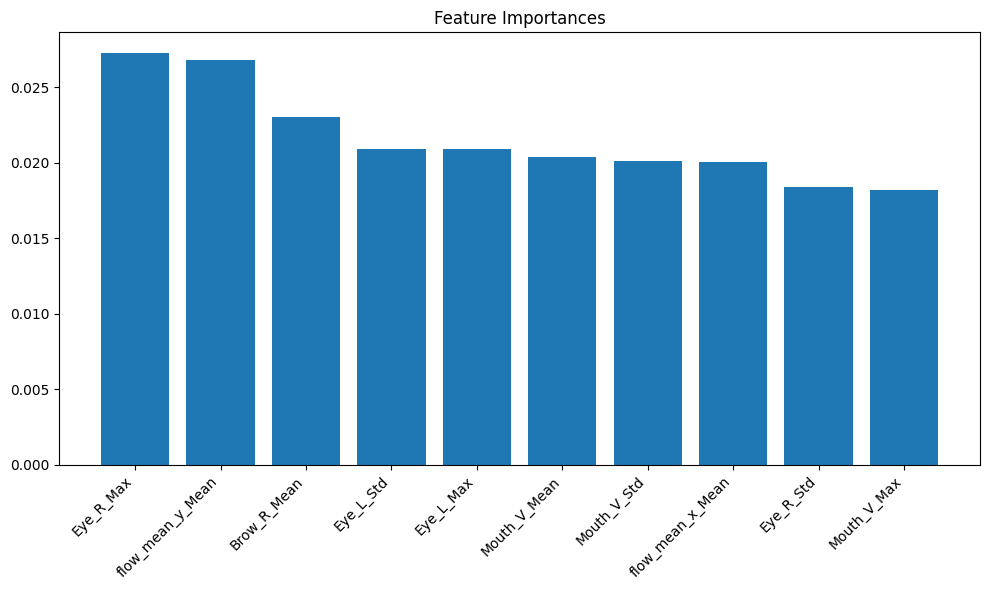

In [ ]:
clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print(f"\n--- Random Forest Results ---")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

import matplotlib.pyplot as plt

feature_names = []
base_names = train_dataset.raw_cols + ['Mouth_V', 'Mouth_H', 'Eye_L', 'Eye_R', 'Brow_L', 'Brow_R']
for stat in ['Mean', 'Std', 'Max', 'Range']:
    for name in base_names:
        feature_names.append(f"{name}_{stat}")

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- Top 10 Most Important Features ---")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()